# E-Commerce Sales Analysis

## Project Objective

This project analyzes e-commerce sales transactions to understand:

-Overall business performance

-Revenue trends

-Product and category performance

-Customer purchasing behavior

-Regional performance

-Delivery performance

-Product return rates

-Discount and sales performance relationships

## Tools

-Python

-Pandas

-Matplotlib

-SQL

-Power BI

## Dataset

E-Commerce Sales Transactions dataset containing 34,500 orders from 7903 unique customers and 24,912 unique products. Each row represents one order.

# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Mount Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# 2. Load Dataset

In [3]:
file_path = "/content/drive/MyDrive/E-Commerce-Sales-Analysis/data/raw/ecommerce_sales_34500.csv"

df = pd.read_csv(file_path)

df.head(10)


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male
5,O100005,C15191,P214062,Beauty,53.91,0.10,2,Credit Card,2024-04-14,5,South,No,97.04,6.32,37.35,35,Female
6,O100006,C13772,P201363,Electronics,266.50,0.00,1,PayPal,2025-05-20,5,East,No,266.50,9.10,22.88,49,Male
7,O100007,C13092,P216691,Beauty,9.98,0.00,1,Credit Card,2023-09-14,4,West,No,9.98,4.51,-0.02,66,Other
8,O100008,C15734,P202751,Fashion,6.61,0.05,1,Debit Card,2023-10-23,6,West,No,6.28,3.43,-1.23,37,Female
9,O100009,C16265,P207782,Grocery,10.91,0.00,1,Credit Card,2023-10-31,6,South,No,10.91,2.76,-1.89,56,Male


# 3.Initial Data Exploration

In [4]:
# Dataset dimensions
print(f"Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.")

# Column names
df.columns.tolist()

# Dataset information
df.info()

# Summary statistics
df.describe()

Dataset contains 34,500 rows and 17 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


# 4. Data Quality Check

In [5]:
# Missing values by column
print("Missing values by column:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values by column:
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Total missing values: 0
Duplicate rows: 0


# 5. Data Type Conversion

In [6]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

print("Order date data type:", df['order_date'].dtype)

Order date data type: datetime64[ns]


# 6. Check the Date Range

In [7]:
print("Start date:", df['order_date'].min())
print("End date:", df['order_date'].max())

Start date: 2023-09-12 00:00:00
End date: 2025-09-11 00:00:00


# 7. Feature Engineering


In [8]:
# Create data features
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

df[['order_date', 'year', 'month', 'year_month']].head(10)

,order_date,year,month,year_month
0,2023-12-23,2023,12,2023-12
1,2025-04-03,2025,4,2025-04
2,2024-10-08,2024,10,2024-10
3,2024-09-14,2024,9,2024-09
4,2024-12-21,2024,12,2024-12
5,2024-04-14,2024,4,2024-04
6,2025-05-20,2025,5,2025-05
7,2023-09-14,2023,9,2023-09
8,2023-10-23,2023,10,2023-10
9,2023-10-31,2023,10,2023-10


In [9]:
# Create return flag
df['return_flag'] = (
    df['returned'] == 'Yes'
).astype(int)

df[['returned', 'return_flag']].head(10)

,returned,return_flag
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0
5,No,0
6,No,0
7,No,0
8,No,0
9,No,0


In [10]:
# Create customer age groups
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[18, 25, 35, 45, 55, 65, 70],
    right=False,
    labels=[
        '18-24',
        '25-34',
        '35-44',
        '45-54',
        '55-64',
        '65-69'
    ]
)

df[['customer_age', 'age_group']].head(10)

,customer_age,age_group
0,60,55-64
1,37,35-44
2,34,25-34
3,21,18-24
4,39,35-44
5,35,35-44
6,49,45-54
7,66,65-69
8,37,35-44
9,56,55-64


# 8. Save Cleaned Data

In [11]:
processed_file_path =(
    '/content/drive/MyDrive/E-Commerce-Sales-Analysis/data/cleaned/ecommerce_sales_cleaned.csv'
)
df.to_csv(processed_file_path, index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# 9. Categorical Data Exploration

In [12]:
# Categorical data exploration

print("Product Categories:")
print(df['category'].value_counts())

print("\nPayment Methods:")
print(df['payment_method'].value_counts())

print("\nRegions:")
print(df['region'].value_counts())

print("\nReturned Orders:")
print(df['returned'].value_counts())

print("\nCustomer Gender:")
print(df['customer_gender'].value_counts())

Product Categories:
category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

Payment Methods:
payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

Regions:
region
South      7584
North      7572
East       6904
West       6808
Central    5632
Name: count, dtype: int64

Returned Orders:
returned
No     32597
Yes     1903
Name: count, dtype: int64

Customer Gender:
customer_gender
Female    16818
Male      16310
Other      1372
Name: count, dtype: int64


# 10. Check Orders and Customers

In [13]:
print("Total rows:", len(df))
print("Unique orders:", df['order_id'].nunique())
print("Unique customers:", df['customer_id'].nunique())
print("Unique products:", df['product_id'].nunique())
print("Duplicate order IDs:", df['order_id'].duplicated().sum())

average_orders_per_customer = (
    df['order_id'].nunique() / df['customer_id'].nunique()
)
print(f"Average orders per customer: {average_orders_per_customer:.2f}")

Total rows: 34500
Unique orders: 34500
Unique customers: 7903
Unique products: 24912
Duplicate order IDs: 0
Average orders per customer: 4.37


Customer Purchase Frequency: The dataset contains 34,500 orders from 7,903 unique customers, resulting in an average of approximately 4.37 orders per customer. This indicates that customers made repeat purchases during the analysis period.

# 11. Overall Business KPIs

In [14]:
total_revenue = df['total_amount'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_products =df['product_id'].nunique()
total_quantity = df['quantity'].sum()

average_order_value = total_revenue / total_orders
return_rate = df['return_flag'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Total Units Sold: {total_quantity:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Return Rate: {return_rate:.2%}")

Total Revenue: $5,865,293.05
Total Orders: 34,500
Total Customers: 7,903
Total Products: 24,912
Total Units Sold: 51,430
Average Order Value: $170.01
Return Rate: 5.52%


# 12. Sales Analysis

### Question 1: How has revenue changed over time?

In [15]:
# Monthly revenue
monthly_revenue = (
    df.groupby('year_month')['total_amount']
    .sum()
    .reset_index()
)

monthly_revenue.columns = ['month', 'revenue']
monthly_revenue



,month,revenue
0,2023-09,151135.60
1,2023-10,262502.74
2,2023-11,240286.91
3,2023-12,255617.03
4,2024-01,217766.09
5,2024-02,228013.98
6,2024-03,248176.28
7,2024-04,265596.66
8,2024-05,264875.23
9,2024-06,234155.38


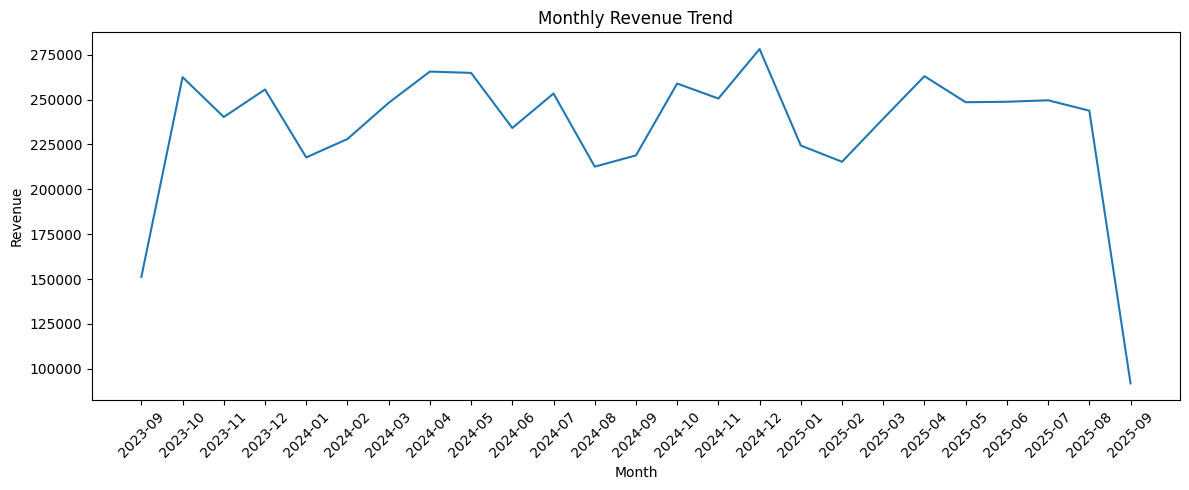

In [16]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue']
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Highest revenue month

highest_month = monthly_revenue.loc[
    monthly_revenue['revenue'].idxmax()
]


# Lowest revenue month

lowest_month = monthly_revenue.loc[
    monthly_revenue['revenue'].idxmin()
]

print("Highest revenue month:")
print(highest_month)

print("\nLowest revenue month:")
print(lowest_month)

Highest revenue month:
month        2024-12
revenue    278154.19
Name: 15, dtype: object

Lowest revenue month:
month       2025-09
revenue    91848.17
Name: 24, dtype: object


Revenue Trend: Revenue fluctuated throughout the analysis period. December 2024 recorded the highest monthly revenue at approximately \$278,154. September 2025 recorded the lowest revenue at approximately \$91,848; however, the dataset only contains data through September 11, 2025, making September an incomplete month. Therefore, September 2025 should not be directly compared with full months. Excluding the incomplete September 2025 data, September 2023 recorded the lowest revenue among the available complete months, at approximately \$151,136.

### Question 2: which categories generate the most revenue?

In [18]:
# Revenue by category
category_revenue = (
    df.groupby('category')['total_amount']
    .sum()
    .sort_values(ascending=False)
)
category_revenue

,total_amount
category,
Electronics,3319206.50
Home,1077681.52
Sports,629825.54
Fashion,471545.80
Beauty,153019.38
Toys,132013.80
Grocery,82000.51


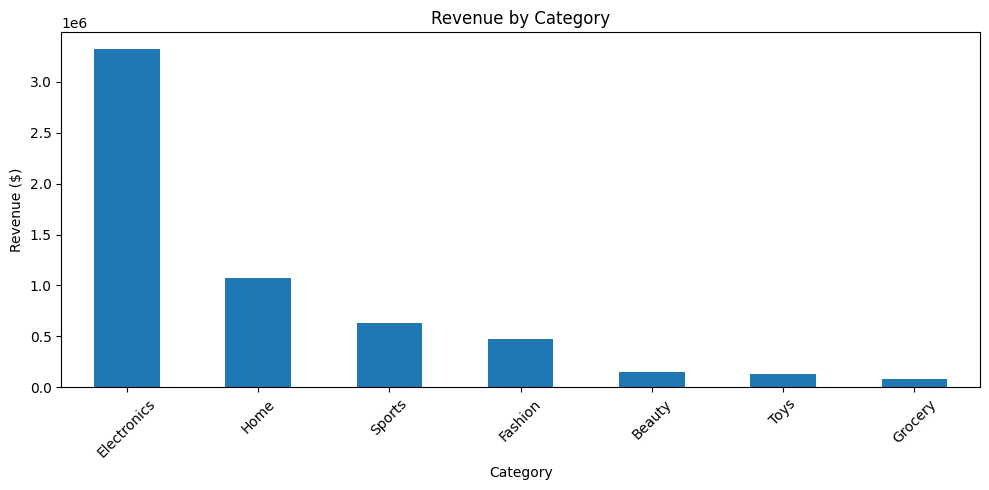

In [19]:
plt.figure(figsize=(10,5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
category_revenue_pct = (
    category_revenue / total_revenue * 100
).round(2)

category_revenue_pct

,total_amount
category,
Electronics,56.59
Home,18.37
Sports,10.74
Fashion,8.04
Beauty,2.61
Toys,2.25
Grocery,1.40


Revenue by Category: Electronics was the company's primary revenue-generating category, generating approximately \$3.32 million, or 56.59% of total revenue. Home was the second-highest category, generating approximately \$1.08 million (18.37%). Together, Electronics and Home accounted for approximately 74.96% of total revenue, indicating that the company's revenue was highly concentrated in these two categories.

Grocery generated the lowest revenue at approximately \$82,001 (1.40%). The company may want to investigate whether Grocery's lower performance is related to factors such as lower product prices, demand, product mix, or sales volume. Because a large share of revenue comes from Electronics and Home, the company may also face some concentration risk if performance in either category declines.

### Question 3: Which regions generate the most revenue?

In [21]:
# Revenue by region
region_revenue = (
    df.groupby('region')['total_amount']
    .sum()
    .sort_values(ascending=False)
)

region_revenue

,total_amount
region,
South,1298096.07
North,1264008.35
West,1186350.50
East,1176334.75
Central,940503.38


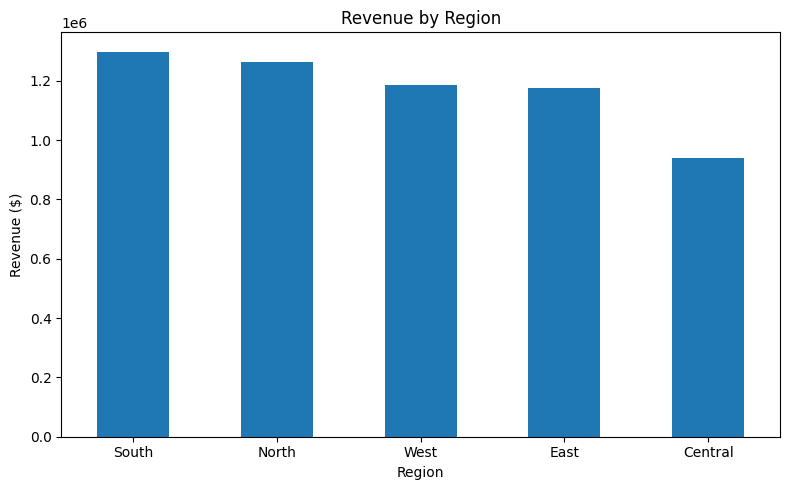

In [22]:
plt.figure(figsize=(8,5))
region_revenue.plot(kind='bar')

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
print("Highest revenue region:")
print(region_revenue.head(1))

print("\nLowest revenue region:")
print(region_revenue.tail(1))

Highest revenue region:
region
South    1298096.07
Name: total_amount, dtype: float64

Lowest revenue region:
region
Central    940503.38
Name: total_amount, dtype: float64


Revenue by Region: The South generated the highest revenue among the five regions, with approximately \$1.30 million in revenue. The Central region generated the lowest revenue, at approximately \$941,000. Although the South outperformed the other regions, revenue was relatively distributed across all five regions rather than being heavily concentrated in a single region. Further analysis could examine whether differences in customer volume, product mix, average order value, or purchasing behavior contribute to the variation in regional revenue.

### Question 4: Which categories sell the most units?

In [24]:
# Units sold by category
category_quantity = (
    df.groupby('category')['quantity']
    .sum()
    .sort_values(ascending = False)
)
category_quantity

,quantity
category,
Electronics,9343
Fashion,9148
Home,8229
Toys,6313
Sports,6244
Beauty,6122
Grocery,6031


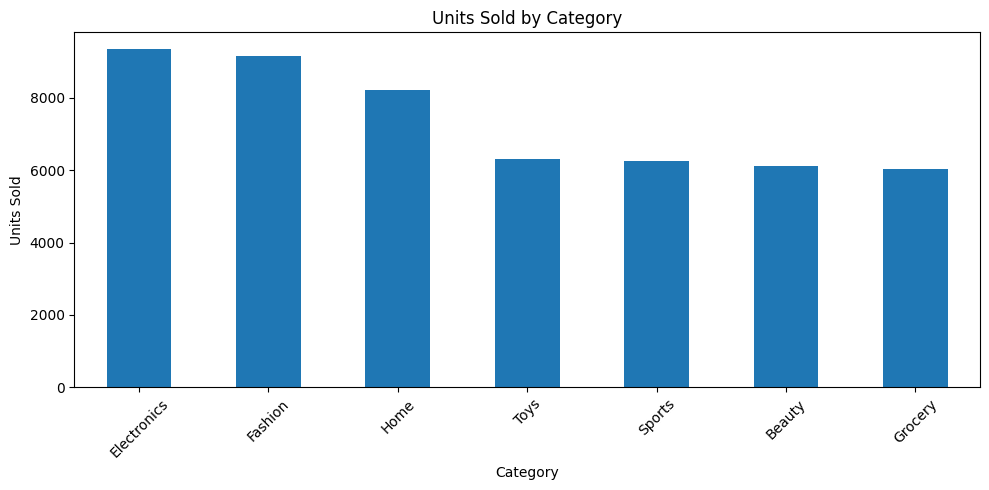

In [25]:
plt.figure(figsize=(10,5))

category_quantity.plot(kind='bar')

plt.title('Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Units Sold by Category: Electronics had the highest number of units sold, with 9,343 units, followed closely by Fashion with 9,148 units. Home ranked third with 8,229 units, while Grocery had the lowest unit sales at 6,031 units. Despite having a similar number of units sold as Fashion, Electronics generated substantially more revenue. This indicates that higher average selling prices and differences in product mix likely contribute to Electronics' stronger revenue performance.

### Question 5: Which products generate the most revenue?

In [26]:
# Revenue by product
product_revenue = (
    df.groupby('product_id')['total_amount']
    .sum()
    .sort_values(ascending = False)
)

top_10_products = product_revenue.head(10)
top_10_products


,total_amount
product_id,
P217031,13035.01
P242326,11747.30
P224743,11298.30
P216077,8035.78
P225406,6786.53
P204291,6279.08
P208695,6227.16
P219612,6032.83
P247375,5662.93


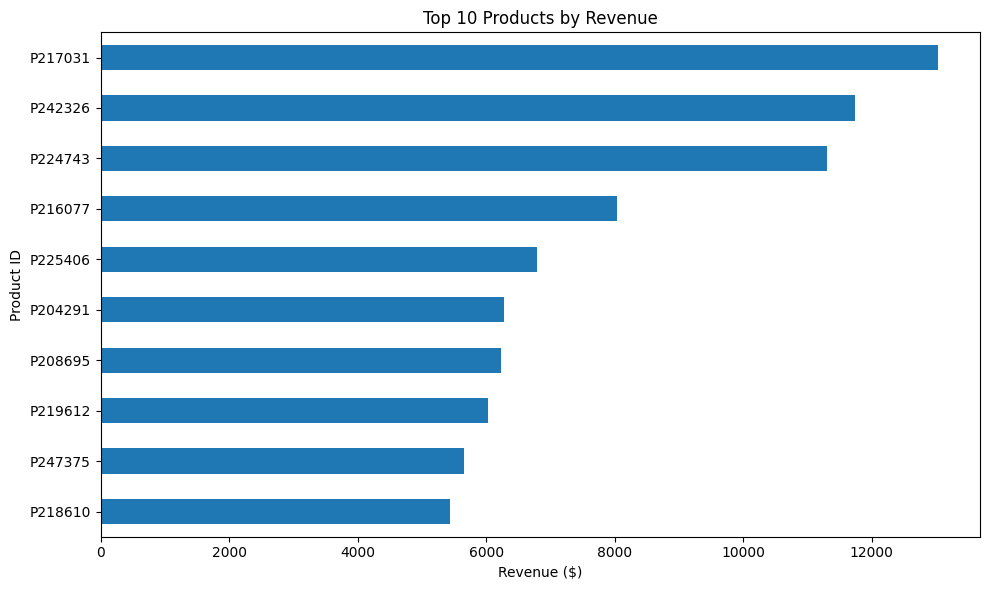

In [27]:
plt.figure(figsize=(10,6))
top_10_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Product ID')

plt.tight_layout()
plt.show()

Top Products by Revenue: Product P217031 generated the highest revenue at approximately \$13,035, followed by P242326 at approximately \$11,747 and P224743 at approximately \$11,298. The remaining products in the top 10 generated between approximately \$5,438 and \$8,036 in revenue. These high-revenue products may be important contributors to overall sales performance and could be analyzed further based on quantity sold, pricing, discount levels, category, and profitability.

### Question 6: Which customers generate the most revenue?

In [28]:
# Revenue by customer

customer_revenue = (
    df.groupby('customer_id')['total_amount']
    .sum()
    .sort_values(ascending = False)
)

top_10_customers = customer_revenue.head(10)
top_10_customers

,total_amount
customer_id,
C16655,13885.10
C13565,11984.28
C15379,11375.58
C17116,7424.34
C15644,7244.07
C10975,7209.12
C16382,6973.06
C13767,6546.60
C15254,6509.95


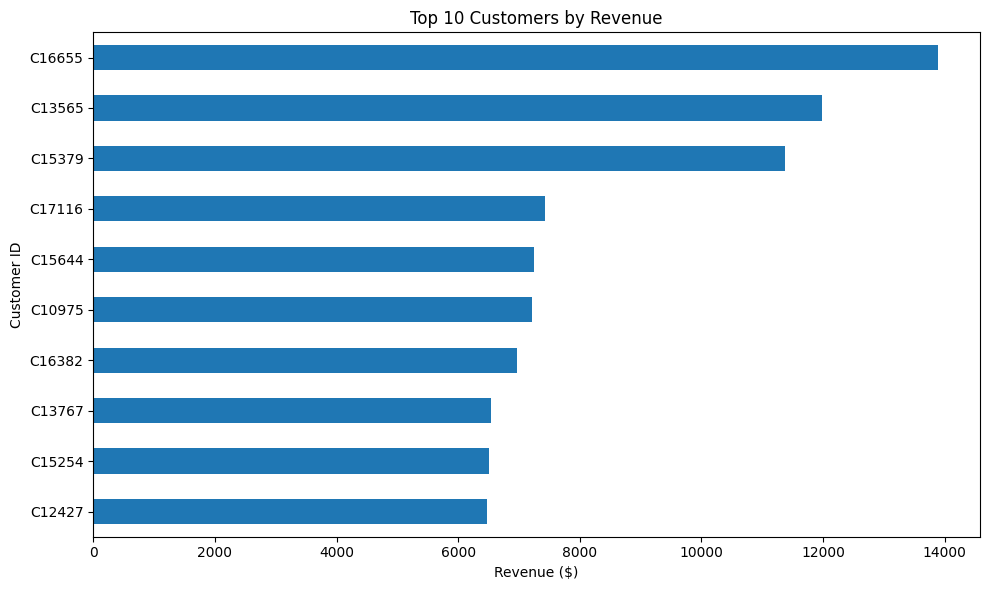

In [29]:
plt.figure(figsize=(10,6))
top_10_customers.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

Top Customers by Revenue: Customer C16655 generated the highest total revenue at approximately \$13,885, followed by C13565 at approximately \$11,984 and C15379 at approximately \$11,376. The remaining customers in the top 10 generated between approximately \$6,480 and \$7,424 in revenue. These high-value customers may represent an important customer segment for retention and customer-value analysis. Further analysis could examine their purchase frequency, preferred product categories, average order value, and profitability.

### Question 7:  How does purchasing behavior differ by gender?

In [30]:
# Customer purchasing behavior by gender
gender_analysis = (
    df.groupby('customer_gender')
    .agg(
        customers = ('customer_id', 'nunique'),
        orders = ('order_id','nunique'),
        revenue =('total_amount', 'sum'),
        quantity=('quantity', 'sum'),
        average_order_value = ('total_amount', 'mean')
    )
)

gender_analysis.round(2)

,customers,orders,revenue,quantity,average_order_value
customer_gender,,,,,
Female,7026,16818,2853296.96,25181,169.66
Male,6981,16310,2793055.33,24260,171.25
Other,1276,1372,218940.76,1989,159.58


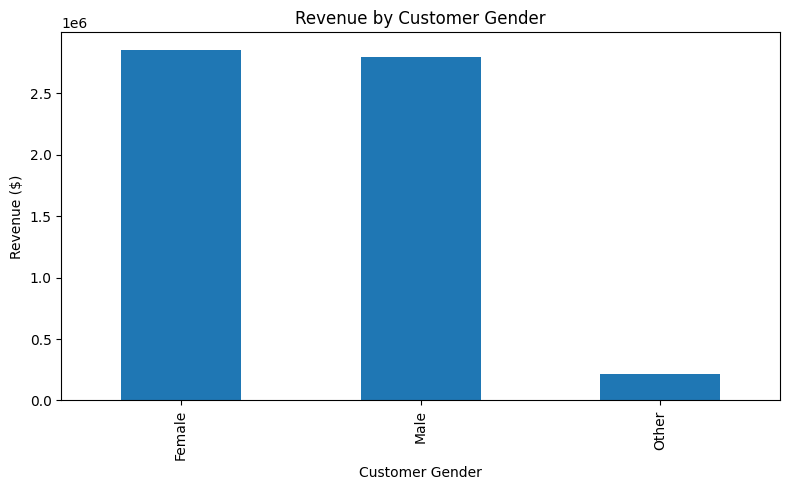

In [31]:
plt.figure(figsize=(8,5))

gender_analysis['revenue'].plot(kind='bar')

plt.title('Revenue by Customer Gender')
plt.xlabel('Customer Gender')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

Purchasing Behavior by Gender: Female customers generated the highest total revenue at approximately \$2.85 million, compared with approximately \$2.79 million from male customers. Female customers also placed slightly more orders (16,818 vs. 16,310) and purchased more units (25,181 vs. 24,260). However, male customers had a slightly higher average transaction value of approximately \$171.25, compared with \$169.66 for female customers. Customers in the Other gender category generated approximately \$218,941 in revenue and had the lowest average transaction value at approximately \$159.58. Overall, purchasing behavior was relatively similar between female and male customers, with only modest differences in revenue, order volume, quantity purchased, and average transaction value.

### Question 8: How does purchasing behavior differ by age group?

In [32]:
# Customer purchasing behavior by age group

age_analysis = (
    df.groupby('age_group', observed=True)
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('order_id','nunique'),
        revenue=('total_amount','sum'),
        quantity=('quantity','sum'),
        average_order_value=('total_amount','mean')
    )
)

age_analysis['revenue_per_customer'] =(
    age_analysis['revenue'] /
    age_analysis['customers']
)

age_analysis.round(2)

,customers,orders,revenue,quantity,average_order_value,revenue_per_customer
age_group,,,,,,
18-24,3465,4555,816408.14,6803,179.23,235.62
25-34,4569,6755,1166858.04,10072,172.74,255.39
35-44,4525,6659,1125028.50,9899,168.95,248.63
45-54,4508,6654,1133888.66,9883,170.41,251.53
55-64,4551,6595,1049028.21,9838,159.06,230.50
65-69,2700,3282,574081.50,4935,174.92,212.62


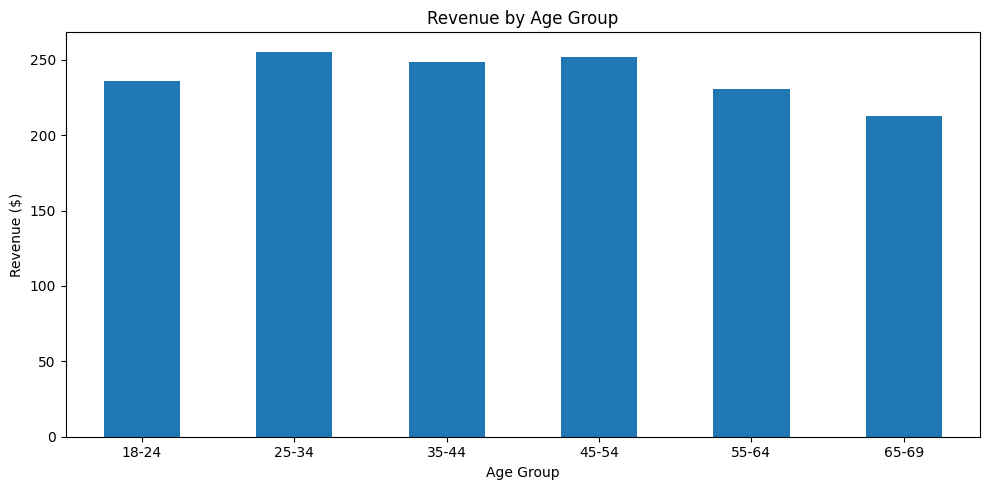

In [33]:
age_analysis['revenue_per_customer'].plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue ($)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Purchasing Behavior by Age Group: Customers aged 25–34 generated the highest total revenue at approximately \$1.17 million and the highest revenue per customer at approximately \$255.39, making this the strongest-performing age segment by these measures. Customers aged 65–69 generated the lowest revenue per customer at approximately \$212.62. The 25–34 segment may therefore be an important customer group for further analysis, particularly to understand its preferred product categories, purchasing frequency, and spending patterns.

### Question 9: What is the average delivery time?

In [34]:
average_delivery = df['delivery_time_days'].mean()
print(f"Average Delivery Time: {average_delivery:.2f} days")

Average Delivery Time: 4.81 days


Delivery Performance: The average delivery time across all transactions was approximately 4.81 days. This provides a baseline measure of overall delivery performance. However, the overall average does not reveal differences across regions or product categories. Further analysis is needed to identify regions or categories with relatively longer delivery times and potential opportunities for improving delivery performance.

### Question 10: Which regions have the longest delivery times?

In [35]:
region_delivery = (
    df.groupby('region')['delivery_time_days']
    .mean()
    .round(2)
    .sort_values(ascending = False)
)

region_delivery


,delivery_time_days
region,
East,5.99
South,5.01
West,5.00
Central,4.01
North,3.98


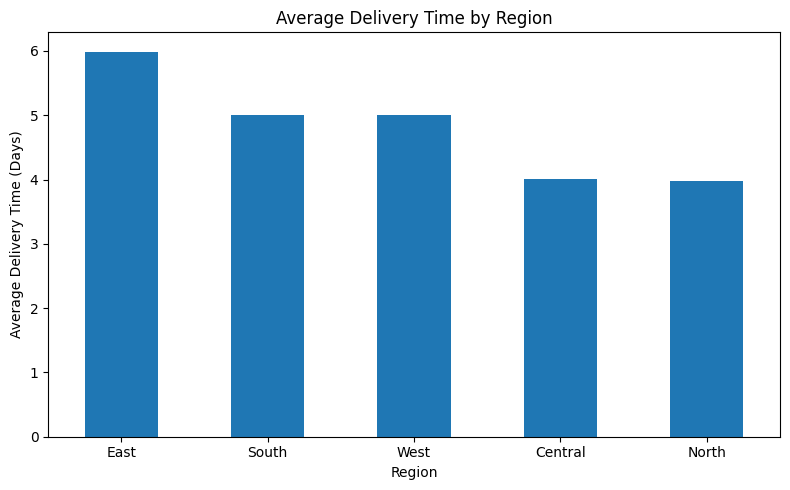

In [36]:
plt.figure(figsize=(8,5))

region_delivery.plot(kind='bar')

plt.title('Average Delivery Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Time (Days)')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Delivery Performance by Region: Delivery performance varied across regions. The East had the longest average delivery time at approximately 5.99 days, while the North had the shortest at approximately 3.98 days, representing a difference of approximately 2.01 days. The South and West had similar average delivery times of approximately 5.01 and 5.00 days, respectively, while Central averaged approximately 4.01 days. The variation in delivery times across regions suggests that delivery performance may warrant further investigation, particularly in the East.

### Question 11: Which categories have the highest return rates?

In [37]:
category_return_rate = (
    df.groupby('category')['return_flag']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending = False)
)

category_return_rate

,return_flag
category,
Fashion,8.28
Electronics,7.30
Home,5.65
Toys,4.94
Sports,4.94
Beauty,3.78
Grocery,1.31


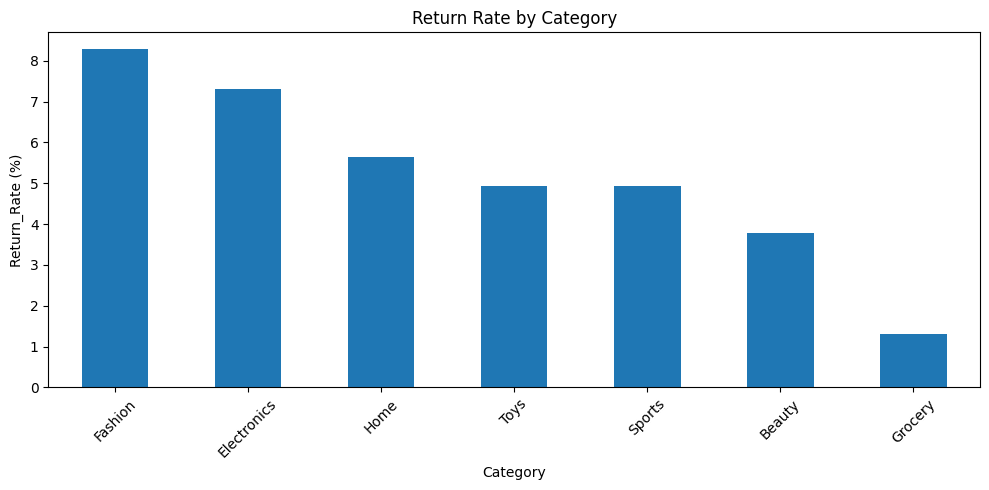

In [38]:
category_return_rate.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Return Rate by Category')
plt.xlabel('Category')
plt.ylabel('Return_Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
print("Highest return rate:")
print(category_return_rate.head(1))

print("\nLowest return rate:")
print(category_return_rate.tail(1))

Highest return rate:
category
Fashion    8.28
Name: return_flag, dtype: float64

Lowest return rate:
category
Grocery    1.31
Name: return_flag, dtype: float64


Return Rate by Category: Return rates varied across product categories. Fashion had the highest return rate at approximately 8.28%, while Grocery had the lowest at approximately 1.31%. The relatively high return rate for Fashion suggests that this category may warrant further investigation. Additional analysis could examine product-level return rates and potential relationships with pricing, discounts, and customer characteristics.

### Question 12: How does discount level relate to sales performance?

In [40]:
discount_analysis = (
    df.groupby('discount')
    .agg(
        transactions=('order_id', 'nunique'),
        revenue=('total_amount', 'sum' ),
        units_sold=('quantity', 'sum'),
        average_orders_value=('total_amount', 'mean')
    )
    .round(2)
    .reset_index()
)

discount_analysis

,discount,transactions,revenue,units_sold,average_orders_value
0,0.00,18939,3388994.91,28307,178.94
1,0.05,6176,1022010.29,9259,165.48
2,0.10,4159,672166.96,6185,161.62
3,0.15,2795,437214.19,4091,156.43
4,0.20,1727,251605.26,2554,145.69
5,0.30,704,93301.44,1034,132.53


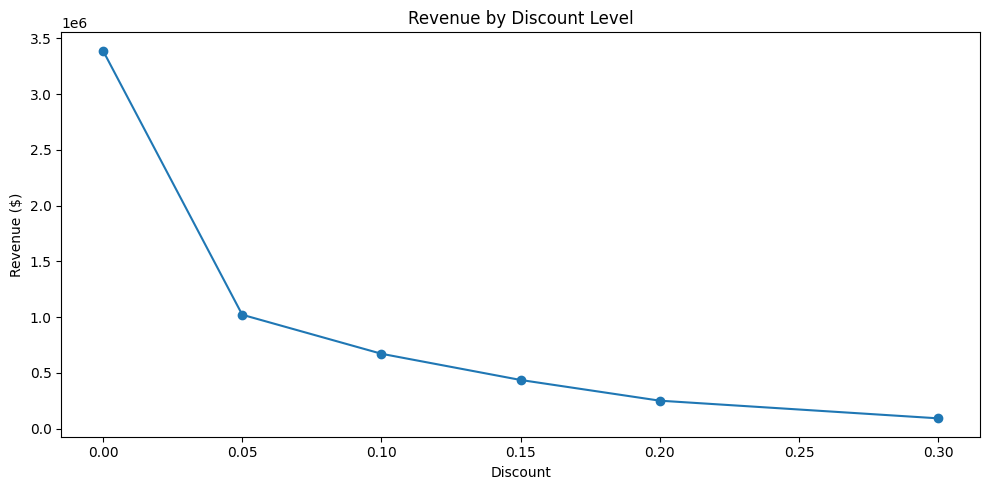

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    discount_analysis['discount'],
    discount_analysis['revenue'],
    marker='o'
)

plt.title('Revenue by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

In [42]:
discount_analysis['revenue_per_transaction'] = (
    discount_analysis['revenue'] /
    discount_analysis['transactions']
)

discount_analysis.round(2)

,discount,transactions,revenue,units_sold,average_orders_value,revenue_per_transaction
0,0.00,18939,3388994.91,28307,178.94,178.94
1,0.05,6176,1022010.29,9259,165.48,165.48
2,0.10,4159,672166.96,6185,161.62,161.62
3,0.15,2795,437214.19,4091,156.43,156.43
4,0.20,1727,251605.26,2554,145.69,145.69
5,0.30,704,93301.44,1034,132.53,132.53


Discount and Sales Performance: Most transactions occurred without a discount, with 18,939 transactions generating approximately \$3.39 million in revenue and an average order value of \$178.94. As the discount increased, transaction volume and average order value generally decreased. Transactions with a 5% discount had an average order value of \$165.48, while transactions with a 30% discount had the lowest average order value at \$132.53. The number of transactions also declined from 18,939 with no discount to only 704 with a 30% discount.

This pattern indicates that higher discount levels were associated with lower transaction volume and lower average order value in this dataset. However, this analysis does not establish that higher discounts caused lower sales, because other factors may influence purchasing behavior and discount assignment.

# 13. Business Insights

1. Electronics was the company's primary revenue-generating category. It generated approximately \$3.32 million in revenue, representing 56.59% of total revenue. Electronics also generated the highest number of units sold and the highest revenue per unit, making it the company's strongest category by revenue performance.

2. Revenue was highly concentrated in Electronics and Home. Together, these two categories generated approximately 74.96% of total revenue, indicating that the company's overall revenue depends heavily on the performance of these two categories.

3. Grocery generated the lowest revenue among the categories. It generated approximately \$82,001 in revenue and approximately 6,031 units sold. Grocery also had the lowest revenue per unit, at approximately \$13.60. Further analysis could examine product prices, product mix, and purchasing behavior within the category.

4. The South generated the highest regional revenue, at approximately \$1.30 million, while Central generated the lowest, at approximately \$941,000. However, revenue was relatively distributed across the five regions rather than being heavily concentrated in one region.
5. Customers aged 25–34 were the strongest-performing age segment. They generated approximately \$1.17 million in total revenue and had the highest revenue per customer, at approximately \$255.39. This customer segment may be useful for further analysis of purchasing frequency and preferred product categories.

6. Purchasing behavior was relatively similar between female and male customers. Female customers generated slightly more total revenue and placed more orders, while male customers had a slightly higher average order value. Overall, the differences between the two groups were relatively modest.

7. Delivery performance varied considerably by region. The East had the longest average delivery time at approximately 5.99 days, while the North had the shortest at approximately 3.98 days, a difference of approximately 2.01 days. The East may therefore warrant further investigation into delivery performance.

8. Return rates varied across product categories. Fashion had the highest return rate at approximately 8.28%, while Grocery had the lowest at approximately 1.31%. The relatively high return rate for Fashion may warrant further investigation into products, pricing, or customer purchasing patterns.

9. Discount levels were associated with differences in sales performance. Transactions without a discount had the highest transaction volume, with 18,939 transactions, and an average order value of approximately \$178.94. At a 30% discount, there were only 704 transactions, with an average order value of approximately \$132.53. This analysis shows an association between higher discount levels and lower transaction volume and average order value, but it does not establish that higher discounts caused lower sales.

10. Monthly revenue fluctuated throughout the analysis period. December 2024 recorded the highest monthly revenue at approximately \$278,154. September 2025 recorded the lowest revenue at approximately \$91,848, but the dataset only contains data through September 11, 2025, making it an incomplete month. Excluding September 2025, September 2023 had the lowest revenue among the available complete months, at approximately \$151,136.
